In [ ]:
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from geopy import distance
import statsmodels.api as sm
from sklearn.metrics import log_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Statistical Exploration of OPTN Data

In Lab 5, we explored the OPTN organ donation data. In one of the steps, we modeled the relationship of various features with the transplant success rate. Let's dive deeper here.

In [ ]:
# read and process data
optn_df = pd.read_sql("SELECT * FROM optn", sqlite3.connect("optn_reduced.sqlite3"))
optn_df["deceased_donor"] = optn_df["deceased_donor"].astype(bool)
optn_df["succeeded_1_year"] = optn_df["succeeded_1_year"].astype(bool)


def transplant_distance_miles(row):
    return distance.distance(
        (row["donor_lat"], row["donor_lon"]),
        (row["transplant_lat"], row["transplant_lon"]),
    ).miles


optn_df["distance_miles"] = optn_df.apply(transplant_distance_miles, axis=1)

# split the data by organ
liver_df = optn_df[optn_df["organ"] == "liver"]
kidney_df = optn_df[optn_df["organ"] == "kidney"]
optn_df.head()

,preservation_hours,recipient_age,donor_age,organ,deceased_donor,succeeded_1_year,donor_lat,donor_lon,transplant_lat,transplant_lon,transplant_year,distance_miles
0,6.1,30-59,60-99,liver,True,True,43.15,-75.18,42.27,-71.76,2017-2024,184.370227
1,5.0,60-99,0-29,liver,True,True,41.25,-75.88,39.96,-75.20,2007-2016,95.925424
2,5.7,30-59,30-59,liver,True,False,38.03,-84.51,35.13,-90.00,2017-2024,364.858865
3,7.5,30-59,60-99,liver,True,True,37.66,-121.02,37.76,-122.46,2007-2016,79.198770
4,5.3,30-59,0-29,liver,True,False,39.70,-104.84,40.66,-111.89,2017-2024,378.821725


## Cold Ischemic Time

In our initial exploration, one of the most influential features that determines liver transplant success is the Cold Ischemic Time (CIT). That is the time that the liver is on ice. Let's further assess this feature.

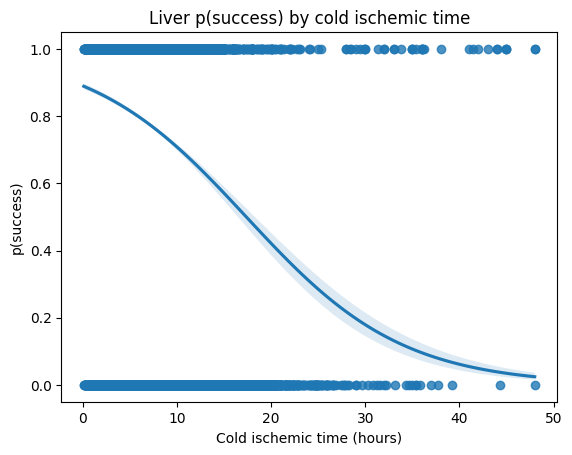

In [388]:
success_df = liver_df[(liver_df["preservation_hours"] > 0)].sample(
    frac=0.2, random_state=42
)

ax = sns.regplot(
    data=success_df,
    x=success_df["preservation_hours"],
    y=success_df["succeeded_1_year"],
    logistic=True,
)
ax.set_title("Liver p(success) by cold ischemic time")
ax.set_xlabel("Cold ischemic time (hours)")
ax.set_ylabel("p(success)")
plt.show()

The fitted logistic regression curve is attempting to relate CIT with the chance of transplant success. And based on the plot, it seems that as the liver stays longer on ice, the chance of success decreases.

Let's poke around with this result. Reading the plot, we see that right around 20 hours, there is a decrease in number of data points, and simultaneously, the blue shadow (i.e. confidence interval) becomes wider. It seems that the model is not as confident about the chance of success as we get longer CIT.

To investigate the model, we first assess if the relationship actually follow a S-shaped trend. One very crude way to do this is to bin the data by CIT and use the proportion of successful transplants in each bin to estimate the probability of success.

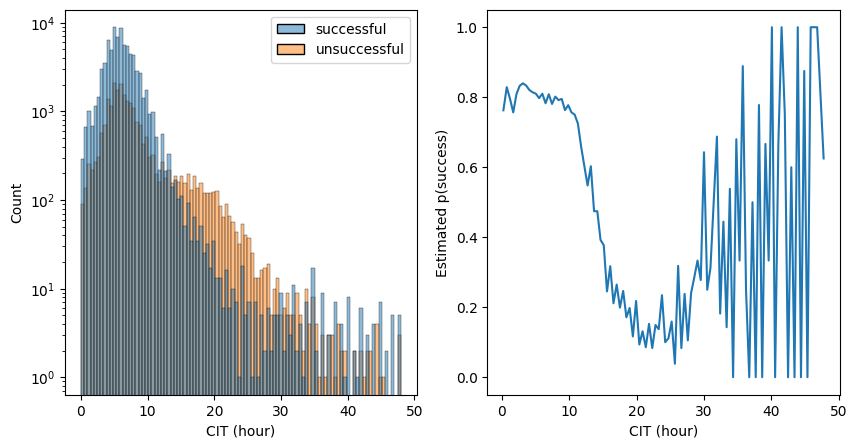

In [389]:
bin_count = 100  # change this to explore

# make a slice of liver_df
bin_df = liver_df.copy()

# Use pd.cut to compute bins
bins, bin_edges = pd.cut(bin_df["preservation_hours"], bins=bin_count, retbins=True)
bin_centers = sorted(bins.apply(lambda x: x.mid).unique())  # bin centers for plotting

# estimate the probability of success
prob_est = bin_df.groupby(bins, observed=True)["succeeded_1_year"].mean()

# rename for labeling
bin_df["succeeded_1_year"] = bin_df["succeeded_1_year"].replace(
    {False: "unsuccessful", True: "successful"}
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# plot 1: histogram of CIT
hist = sns.histplot(
    data=bin_df,
    x="preservation_hours",
    bins=bin_edges,
    ax=axes[0],
    hue="succeeded_1_year",
)
axes[0].set_yscale("log")
axes[0].set_xlabel("CIT (hour)")
hist.legend_.set_title(None)

# plot 2: estimated probability of success
axes[1].plot(bin_centers, prob_est)
axes[1].set_xlabel("CIT (hour)")
axes[1].set_ylabel("Estimated p(success)")

plt.show()

<span style="color: red">I do not like using a parasite axis like the following in general. But maybe it's a good visualization in this case since it really shows the effect of the lack of data? Feel free to choose one of these two plots.</span>

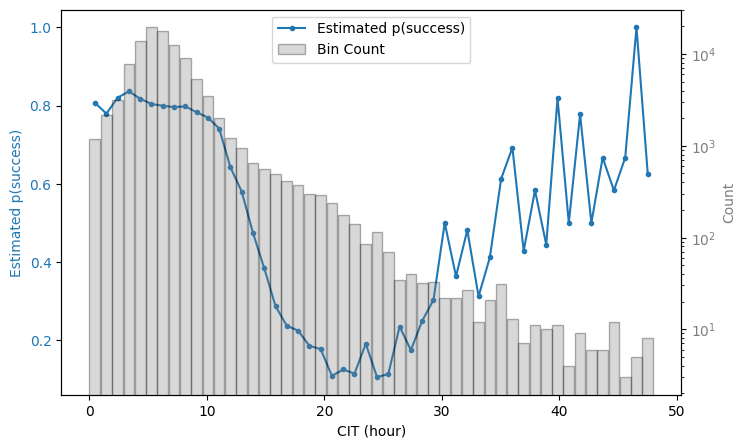

In [390]:
bin_count = 50  # change this to explore

# make a slice of liver_df
bin_df = liver_df.copy()

# Use pd.cut to compute bins
bins, bin_edges = pd.cut(bin_df["preservation_hours"], bins=bin_count, retbins=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# estimate the probability of success
prob_est = bin_df.groupby(bins, observed=False)["succeeded_1_year"].mean()
prob_est.index = bin_centers  # replace Interval index with numeric centers

# histogram counts for plotting
hist_counts, _ = np.histogram(bin_df["preservation_hours"], bins=bin_edges)

fig, ax1 = plt.subplots(figsize=(8, 5))

# left y-axis: probability of success
color_prob = "tab:blue"
(prob_line,) = ax1.plot(
    bin_centers,
    prob_est,
    color=color_prob,
    marker="o",
    label="Estimated p(success)",
    markersize=3,
)
ax1.set_xlabel("CIT (hour)")
ax1.set_ylabel("Estimated p(success)", color=color_prob)
ax1.tick_params(axis="y", labelcolor=color_prob)

# right y-axis: histogram counts
color_hist = "tab:gray"
ax2 = ax1.twinx()
hist_bars = ax2.bar(
    bin_centers,
    hist_counts,
    width=(bin_edges[1] - bin_edges[0] - 0.1),
    alpha=0.3,
    color=color_hist,
    label="Bin Count",
    align="center",
    edgecolor="black",
)
ax2.set_yscale("log")
ax2.set_ylabel("Count", color=color_hist)
ax2.tick_params(axis="y", labelcolor=color_hist)

# combine the legends of the two plots
artists = [prob_line] + ([hist_bars] if hist_counts.any() else [])
labels = [art.get_label() for art in artists if not art.get_label().startswith("_")]
artists_filtered = [art for art in artists if not art.get_label().startswith("_")]
ax1.legend(artists_filtered, labels, loc="upper center")

plt.show()

We see that before we hit around 20-25 CIT, the estimated probability of success roughly follows the S-shape curve. But after that threshold, we don't see a pattern. In some choices of bin sizes, we even see an increase in success rate; though this pattern shouldn't be trusted as the trend is too noisy. If we look at the histogram counting the number of points in each bin, it is very likely that the chao in this region is a result of insufficient data; in fact, only 0.5% of the liver data report CIT longer than 24 hours. 

Why does logistic regression still show a very low sucees rate for large CIT, then? This has to do with **model assumption**: Logistic regression assumes the data has an S-shaped relationship, and all it does is to find the best "S" that fits the data, regardless of the true shape of the relationship. This is why it is crucial to perform model checking when you are performing a statistical analysis: your result can only be as good as your assumptions.

So what is the CIT story here? We should be confident to say that when you have a CIT for, say, less than a day, a longer CIT is associated with lowered transplant success. For CIT longer than a day, we need to study the particular instance or look into other features to reason about success rate. Let's then revisit the initial logsitc regression plot. We now know the result for CIT > 25 is noisy and only accounts for 0.5% of the data, yet in the plot, those data occupy half the area. Let's exclude those data and produce a more realistic visualization.

**Note**: Throwing out the outlier data does not mean they are not useful. In this case, it would actually be quite important to study those data points reason about their formation. Feel free to explore! 

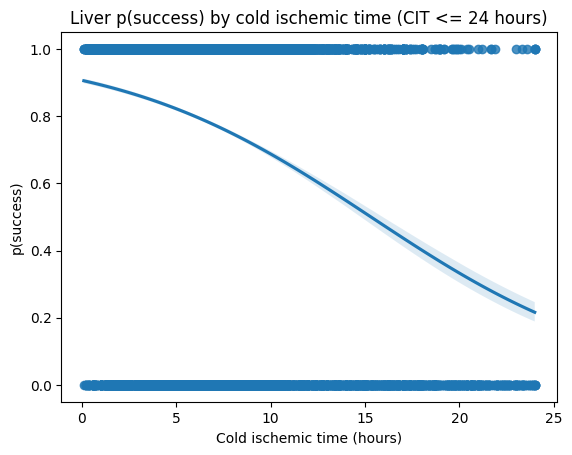

In [391]:
success_df = liver_df[
    (liver_df["preservation_hours"] > 0) & (liver_df["preservation_hours"] <= 24)
].sample(frac=0.2, random_state=42)

ax = sns.regplot(
    data=success_df,
    x=success_df["preservation_hours"],
    y=success_df["succeeded_1_year"],
    logistic=True,
)
ax.set_title("Liver p(success) by cold ischemic time (CIT <= 24 hours)")
ax.set_xlabel("Cold ischemic time (hours)")
ax.set_ylabel("p(success)")
plt.show()

## Building a Bigger Model

Next, let's try combining different features in our dataset to build a bigger and better model. We will use our logistic regression model from the last section as a baseline to see how much we can improve; we focus on data with CIT <= 24 hours for simplicity.

In [ ]:
# get the data
liver_df = liver_df[liver_df["preservation_hours"] <= 24]
cit = StandardScaler().fit_transform(
    liver_df["preservation_hours"].values.reshape(-1, 1)
)
cit = sm.add_constant(cit)
y = liver_df["succeeded_1_year"]

# re-implement the logistic regression model using statsmodels package
baseline_model = sm.Logit(y, cit)
baseline_result = baseline_model.fit(maxiter=500, disp=False)

The logistic regression model from `statsmodels`' comes with some statistical summary that we will look at later. For now, we compute the **cross-entropy loss** (also called **log loss**), which will be our main metric of comparison. 

In [404]:
log_loss(y, baseline_result.predict(cit))

0.5080710991452573

To build our full model, we need to process some features first. Particularly, the `*_age` and `transplant_year` columns are strings that represent categories; a statistical model can only take in numerical values as input. We use a technique called **one-hot encoding** to make these columns numeric. One-hot encoding takes every distinct value of a column, and make each value a new column that has ``True`` if a data point has that value, and ``False`` otherwise.

In [405]:
# drop target variable and organ
X = liver_df.drop(columns=["succeeded_1_year", "organ"])

# one-hot encode the categorical variables
X_encoded = pd.get_dummies(
    X,
    columns=[
        "recipient_age",
        "donor_age",
        "transplant_year",
    ],
    drop_first=True,
)

X_encoded.head()

,preservation_hours,deceased_donor,donor_lat,donor_lon,transplant_lat,transplant_lon,distance_miles,recipient_age_30-59,recipient_age_60-99,donor_age_30-59,donor_age_60-99,transplant_year_1997-2006,transplant_year_2007-2016,transplant_year_2017-2024
0,6.1,True,43.15,-75.18,42.27,-71.76,184.370227,True,False,False,True,False,False,True
1,5.0,True,41.25,-75.88,39.96,-75.20,95.925424,False,True,False,False,False,True,False
2,5.7,True,38.03,-84.51,35.13,-90.00,364.858865,True,False,True,False,False,False,True
3,7.5,True,37.66,-121.02,37.76,-122.46,79.198770,True,False,False,True,False,True,False
4,5.3,True,39.70,-104.84,40.66,-111.89,378.821725,True,False,False,False,False,False,True


A key step in building a model is to determine what variables to include in the model. For simplicity, we will use a fairly automatic and partial technique, called lasso regression (or L1 regularization) for feature selection. As with more sophisicated models we will fit later, we use a package called `scikit-learn`, which is a very popular machine learning library. Lasso regression looks for redundant features (called **collinearity**) that can cause instability in the model and assign these features a near-zero coefficient.

In [406]:
# Build a pipeline that first scales (required by lasso), then runs lasso
lasso_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("lasso", LogisticRegression(penalty="l1", solver="saga", max_iter=1000)),
    ]
)

# Fit the pipeline to the one-hot encoded features and target variable
lasso_pipe.fit(X_encoded, liver_df["succeeded_1_year"])

# get the absolute values of the coefficients (we only care about closeness to 0)
lasso_coef = abs(lasso_pipe.named_steps["lasso"].coef_)

# print results in a dataframe
pd.DataFrame({"|coef|": lasso_coef.flatten()}, index=X_encoded.columns).sort_values(
    "|coef|", ascending=False
)

,|coef|
transplant_year_2007-2016,0.736345
preservation_hours,0.480975
transplant_year_1997-2006,0.380363
transplant_year_2017-2024,0.287023
donor_age_60-99,0.144001
deceased_donor,0.138182
donor_age_30-59,0.101235
transplant_lon,0.076944
donor_lon,0.024263
donor_lat,0.018452


We will probably drop `transplant_lat`, `recipient_age_60-99`, and `recipient_age_30-59`. Note that ideally, we will also check properties of features beyond redundancy (such as stability and predictability), but we make some simplifications.

In [407]:
cols_to_drop = ["transplant_lat", "recipient_age_60-99", "recipient_age_30-59"]
X_encoded = X_encoded.drop(columns=cols_to_drop)

Now let's fit a logistic regression model with these features.

In [408]:
# Re-align X_encoded index with y before fitting model
X_full_model = X_encoded.astype(float)  # cast booleans

# Standardize the features for use with statsmodels
X_full_model = pd.DataFrame(
    StandardScaler().fit_transform(X_full_model),
    columns=X_full_model.columns,
    index=X_full_model.index,  # ensure index is preserved
)
X_full_model = sm.add_constant(X_full_model)

# Fit the logistic regression using the standardized data
log_model = sm.Logit(y.astype(float), X_full_model)
log_result = log_model.fit(maxiter=500, disp=False)

# cross-entropy loss
print(f"Cross-entropy loss: {log_loss(y, log_result.predict(X_full_model)):.4f}")

Cross-entropy loss: 0.4881


The cross-entropy loss is only slightly lower than the baseline. Let's take a look at the model summary.

In [409]:
print(log_result.summary2())

                              Results: Logit
Model:                  Logit              Method:             MLE        
Dependent Variable:     succeeded_1_year   Pseudo R-squared:   0.074      
Date:                   2026-04-23 08:59   AIC:                101271.0275
No. Observations:       103712             BIC:                101385.6200
Df Model:               11                 Log-Likelihood:     -50624.    
Df Residuals:           103700             LL-Null:            -54684.    
Converged:              1.0000             LLR p-value:        0.0000     
No. Iterations:         6.0000             Scale:              1.0000     
--------------------------------------------------------------------------
                           Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
--------------------------------------------------------------------------
const                      1.3732   0.0082 167.6053 0.0000  1.3571  1.3892
preservation_hours        -0.4810   0.0081 -59.1633 0.0

If we are satisfied with the model, we would look at the coefficients and assess each feature's influence on the learned probability of transplant succcess. However, there are some evidence that the model is not ideal here. First, we saw that the cross-entropy loss is only slightly lower than that of the model using a single feature. Second, in the model summary, the Pseudo R-squared, which is a metric that measures model fitness to the data (compared to if we just always predict the most common outcome). This ties back to our earlier discussion of model misspecification. A Pseudo R-squared of 0.074 is rather low, signaling model misfit.

### A more flexible model

It doesn't seem like logistic regression is a good model for our data. Logistic regression is a relatively simple *linear* model (here linear means something more complicated than just $y=x$, but it's in the same spirit). So let's do something more complicated. **Random forest** is a machine learning algorithm widely used in practice. It relies on these decision *trees** that can be viewed as pathways to split the data. Let's fit a random forest model over the data.

In [410]:
# make and fit rf model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_features=0.33,
    min_samples_leaf=5,
)
rf.fit(X_encoded, y)

# measure
rf_probs = rf.predict_proba(X_encoded)[:, 1]
rf_logloss = log_loss(y, rf_probs)
print(f"Random forest log loss: {rf_logloss:.4f}")


Random forest log loss: 0.3510


We see the cross-entropy loss drop significantly. This may look like good new at first glance and motivates you to use this model. However, we need to again be careful about the analysis. With a more flexible model, a concerning phenominon is **overfitting**. This is when a model essentially memorizes the input-output pairs of the data instead of learning the true relationship between them. This can severely corrupt our analysis on which features are the most influential at determining transplant success.

The way to detect overfitting is simple. We split our data into 2 sets: a training set and a test test. We only train the model on the training set, and evaluate its performance on both sets. If the model tends to overfit on the training set, there should be a big difference between the performance on the training set and the test set.

In [411]:
# make and fit rf model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_features=0.33,
    min_samples_leaf=5,
)

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
rf.fit(X_train, y_train)

# measure train and test log loss
rf_probs_train = rf.predict_proba(X_train)[:, 1]
rf_logloss_train = log_loss(y_train, rf_probs_train)
print(f"Random forest train log loss: {rf_logloss_train:.4f}")

rf_probs_test = rf.predict_proba(X_test)[:, 1]
rf_logloss_test = log_loss(y_test, rf_probs_test)
print(f"Random forest test log loss: {rf_logloss_test:.4f}")

Random forest train log loss: 0.3482
Random forest test log loss: 0.4887


The train and test log loss differ by a lot, and the test log loss is very similar to the loss we have seen with logistic regression. It does seem like the model is overfitting and we need to be cautious when drawing conclusions from the model. If, say, we determine that the model is healthy and would like to assess which features are inflential in determining chance of success, we can use a metric called feature importance.

In [412]:
importances = rf.feature_importances_
feature_names = (
    X_encoded.columns
    if hasattr(X_encoded, "columns")
    else [f"feature_{i}" for i in range(len(importances))]
)
pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values(
    "importance", ascending=False
).reset_index(drop=True)

,feature,importance
0,preservation_hours,0.329161
1,distance_miles,0.166539
2,donor_lon,0.144474
3,donor_lat,0.143194
4,transplant_lon,0.107959
5,transplant_year_2017-2024,0.039468
6,transplant_year_2007-2016,0.038060
7,donor_age_30-59,0.011809
8,transplant_year_1997-2006,0.009912
9,donor_age_60-99,0.007290


## Conclusion

We have tried a bunch of models and it does not seem like we have improved much from the single-feature logistic regression model. Here are some potential reasons. 

- **Class imbalance**: About 77% of the data are successful transplants. This means that if the model simply outputs a probability of 1 for every data point, it would have been correct 77% of the time. This is a pretty high baseline to surpass.
- **Lack of more meaningful features**: The goal is to study transplant success. And all the features we have are regarding the transportation of the organ instead of the medical status of the patients. So it is very possible that few of the features we have are truly inflential compared to medical features.

What is interesting is that despite these concerns, we still see lots of tempting results (that turn out to be unstable or not realistic) along the modeling process. This is why checking and diagnosing a model is equally (if not more) important as building the model itself.